In [ ]:
import clustergram
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from meteora import clients
from sklearn import linear_model, pipeline, preprocessing
from sktime.forecasting import auto_reg, compose

from swiss_uhi_lcd import plot_utils, regr_utils

# set seaborn style
sns.set_style("whitegrid")


def ols_by_station(ref_ts_df, long_ts_df, y_col, *, max_window_hours=6):
    """OLS by station."""
    msr = regr_utils.MultiScaleRegression(ref_ts_df)
    # window_minutes = [15, 30] + [60 * i for i in range(1, max_window_hours + 1)]
    window_minutes = [60 * i for i in range(1, max_window_hours + 1)]
    params_df = pd.DataFrame()
    fit_dict = {}
    for station_id, station_ts_df in long_ts_df.groupby("station_id"):
        X_df = msr.get_regr_df(
            station_ts_df,
            y_col,
            window_minutes,
            add_scale_to_col_name=True,
            rescale=False,
        )
        variables = X_df.columns.drop(["time", y_col])
        X_scaled_df = pd.DataFrame(
            preprocessing.StandardScaler().fit_transform(X_df[variables]),
            index=X_df.index,
            columns=variables,
        )
        res = sm.OLS(X_df[y_col], sm.add_constant(X_scaled_df)).fit()
        # print(station_id)
        # print(res.summary())
        params_df = pd.concat(
            [
                params_df,
                res.params.drop("const")
                .reset_index()
                .assign(**{"station_id": station_id}),
            ]
        )
        fit_dict[station_id] = res.rsquared
    params_df = params_df.rename(columns={"index": "variable", 0: "value"})
    params_df["variable"] = params_df["variable"].str.split("_").str[:-1].str.join("_")

    return params_df, fit_dict

In [ ]:
region = "Zollikofen"
ts_df_filepath = "../data/raw/parallel-2025-int.csv"

y_col = "$\Delta$T"

# viz
col_wrap = 4
figwidth = plt.rcParams["figure.figsize"][0]
figheight = plt.rcParams["figure.figsize"][1]

<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_127721/4100763350.py:4: SyntaxWarning: invalid escape sequence '\D'
  y_col = "$\Delta$T"


We first read the parallel LCD temperature measurements at Zollikofen:

In [ ]:
ts_df = (
    pd.read_csv(ts_df_filepath, parse_dates=["time"])
    .set_index("time")
    .resample("h")
    .mean()
)
ts_df.head()

,Prof,Abilum_2,Abilium_2_black,Decentlab,Barani,Koalasense,Onset_big,Onset_small
time,,,,,,,,
2025-07-27 00:00:00,15.533333,15.053025,NaN,NaN,15.200000,15.133333,15.334000,14.860000
2025-07-27 01:00:00,15.450000,14.956448,NaN,NaN,15.100000,14.983333,15.278667,14.700667
2025-07-27 02:00:00,15.366667,14.934641,NaN,NaN,15.083333,14.950000,15.191000,14.684833
2025-07-27 03:00:00,15.416667,14.929745,NaN,NaN,15.100000,14.983333,15.211000,14.704333
2025-07-27 04:00:00,14.883333,14.434399,NaN,NaN,14.616667,14.466667,14.907667,14.285833


We will now use [meteora](https://github.com/martibosch/meteora) to get the reference meteorological data from the MeteoSwiss Zollikofen (BER) station:

In [ ]:
client = clients.MeteoSwissClient(region)
ref_ts_df = (
    client.get_ts_df(
        [
            "temperature",
            "radiation_shortwave",
            "wind_speed",
            "wind_direction",
            "relative_humidity",
            "precipitation",
        ],
        start=ts_df.index.min(),
        end=ts_df.index.max(),
    )
    .droplevel("station_id")
    .resample("h")
    .mean()
)
ref_ts_df.head()

,temperature,radiation_shortwave,wind_speed,wind_direction,relative_humidity,precipitation
time,,,,,,
2025-07-27 00:00:00,15.533333,0.000000,2.466667,172.333333,93.116667,0.000000
2025-07-27 01:00:00,15.450000,0.000000,2.616667,170.833333,93.316667,0.016667
2025-07-27 02:00:00,15.366667,0.000000,2.000000,175.500000,93.300000,0.000000
2025-07-27 03:00:00,15.416667,0.000000,2.016667,180.333333,92.516667,0.000000
2025-07-27 04:00:00,14.883333,11.166667,1.633333,200.833333,94.316667,0.000000


We now compute a time series with the *temperature biases* ($\Delta T$), i.e., difference between the temperature measurements at each LCD and the MeteoSwiss station into a long data frame:

In [ ]:
# get diff data in long form
long_ts_df = (
    ts_df.drop(columns="Prof")
    .sub(ts_df["Prof"], axis="rows")
    .rename_axis(columns="station_id")
    .stack()
    .rename(y_col)
    .reset_index()
)
long_ts_df.head()

,time,station_id,$\Delta$T
0,2025-07-27,Abilum_2,-0.480308
1,2025-07-27,Barani,-0.333333
2,2025-07-27,Koalasense,-0.400000
3,2025-07-27,Onset_big,-0.199333
4,2025-07-27,Onset_small,-0.673333


In [ ]:
daily_ts_df = (
    long_ts_df.set_index("time")
    .groupby("station_id")
    .resample("h")
    .mean()
    .reset_index()
)
daily_ts_df["hour"] = daily_ts_df["time"].dt.hour

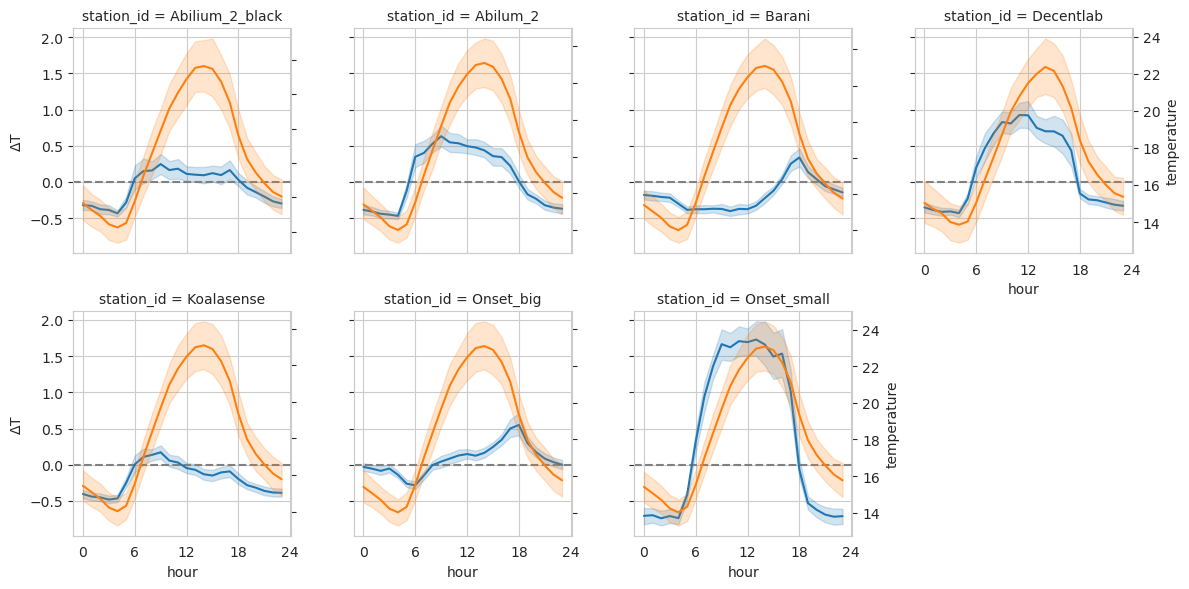

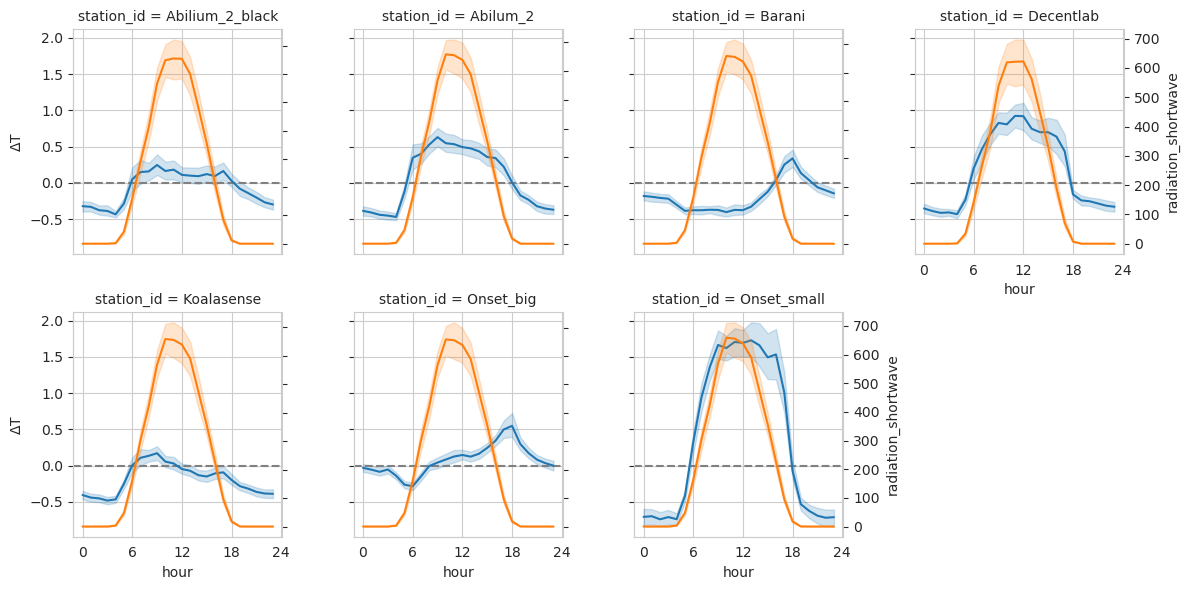

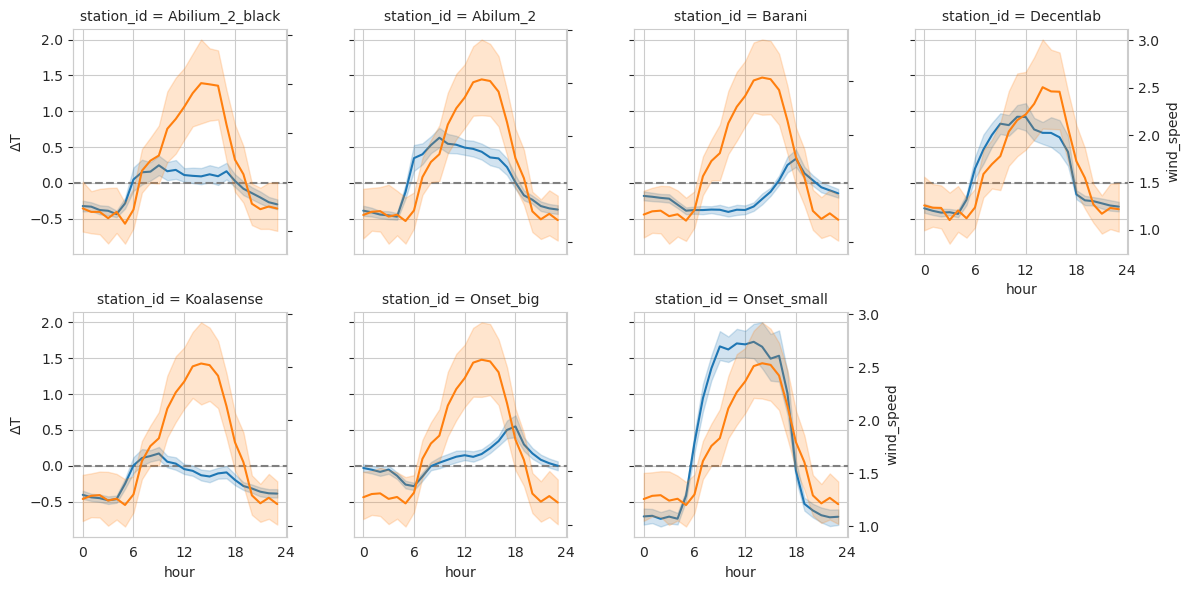

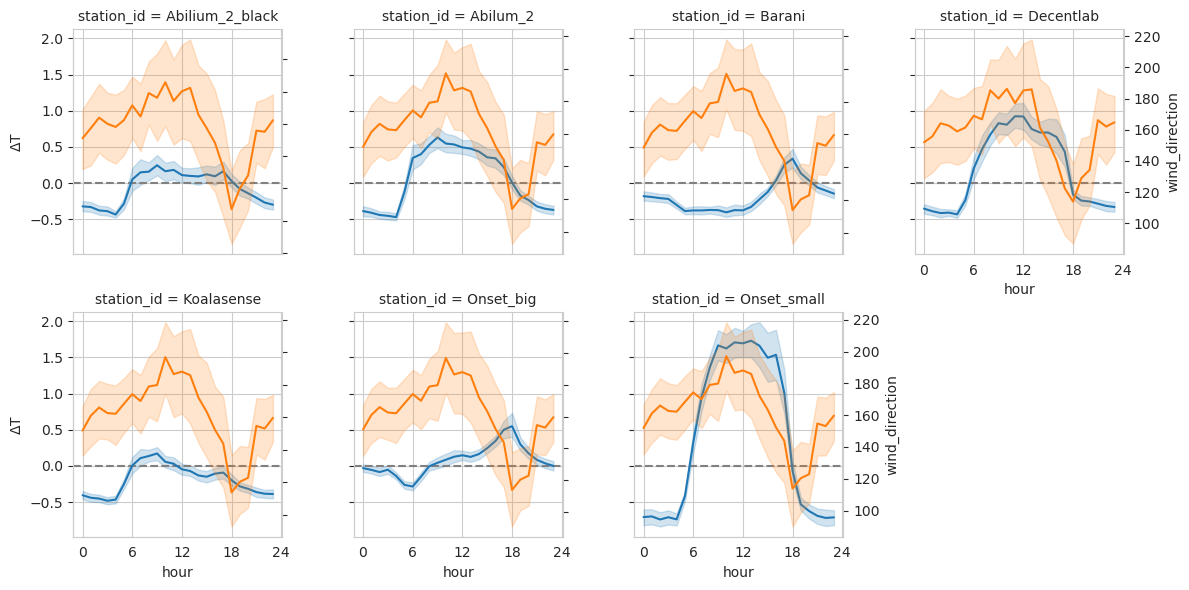

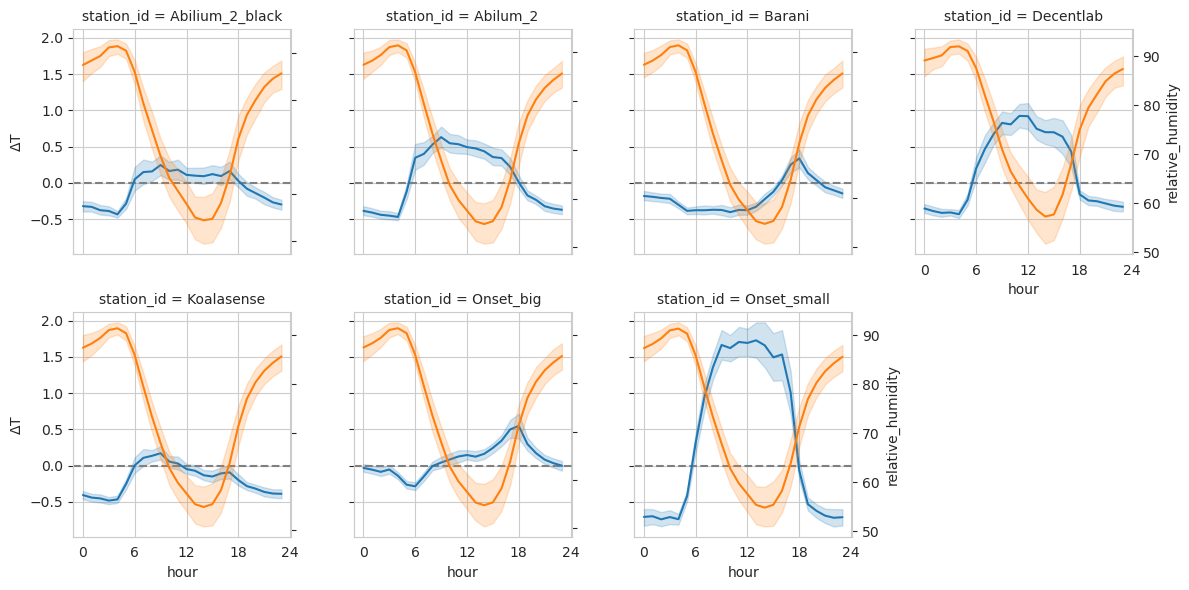

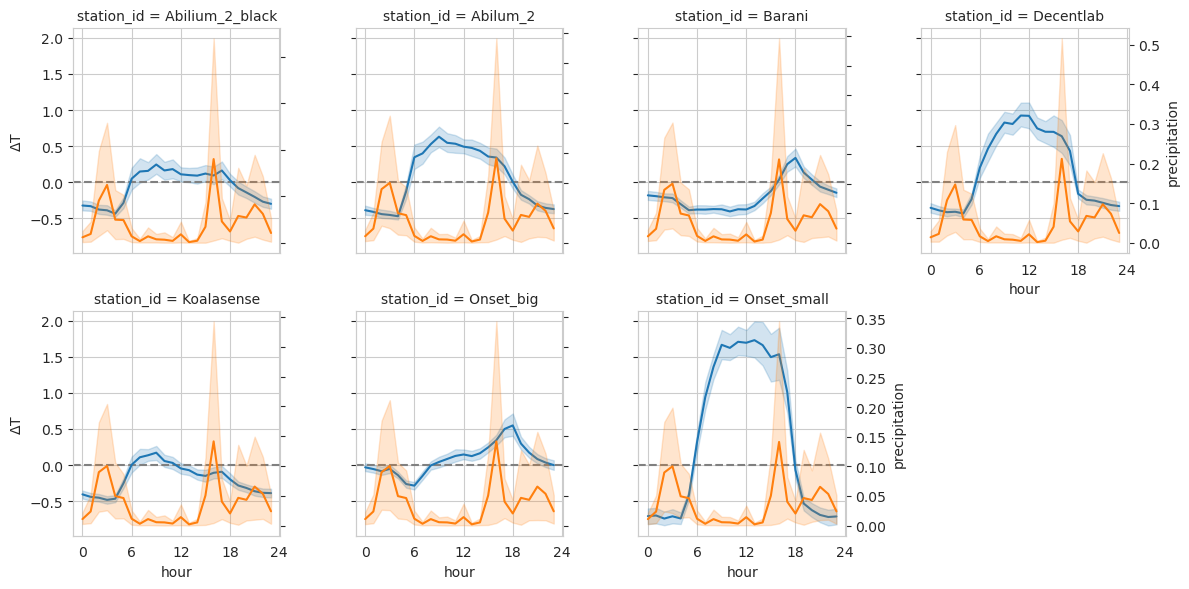

In [ ]:
for variable in ref_ts_df.columns:
    g = plot_utils.facet_twinx_lineplot(
        daily_ts_df, ref_ts_df, variable, y_col, col_wrap=col_wrap
    )
    # g.figure.suptitle(variable)

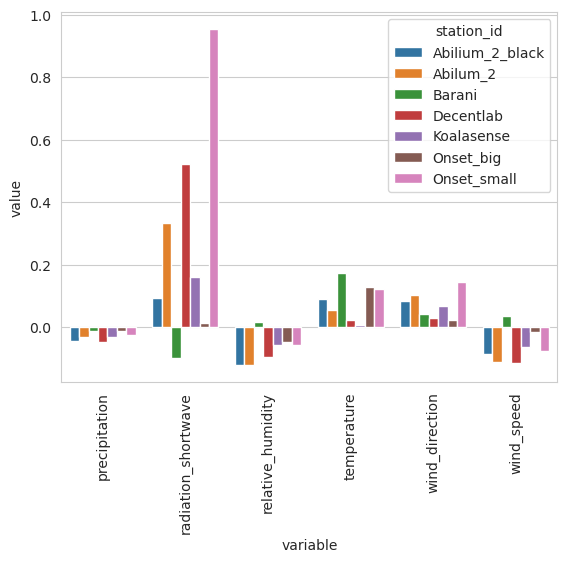

In [ ]:
max_window_hours = 6
params_df, fit_dict = ols_by_station(
    ref_ts_df, long_ts_df, y_col, max_window_hours=max_window_hours
)
ax = sns.barplot(params_df, x="variable", y="value", hue="station_id")
ax.tick_params(axis="x", labelrotation=90)

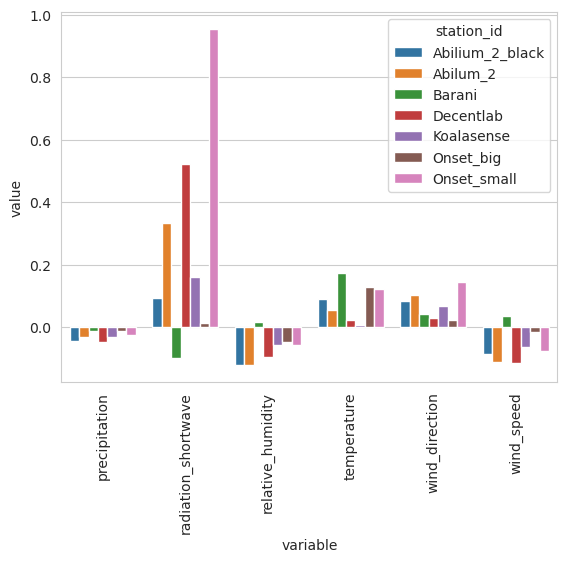

In [ ]:
def _by_station(ref_ts_df, long_ts_df, y_col, *, max_window_hours=6):
    msr = regr_utils.MultiScaleRegression(ref_ts_df)
    # window_minutes = [15, 30] + [60 * i for i in range(1, max_window_hours + 1)]
    window_minutes = [60 * i for i in range(1, max_window_hours + 1)]
    params_df = pd.DataFrame()
    fit_dict = {}
    for station_id, station_ts_df in long_ts_df.groupby("station_id"):
        X_df = msr.get_regr_df(
            station_ts_df,
            y_col,
            window_minutes,
            add_scale_to_col_name=True,
            rescale=False,
            eval_func="spearmanr",
        )
        variables = X_df.columns.drop(["time", y_col])
        X_scaled_df = pd.DataFrame(
            preprocessing.StandardScaler().fit_transform(X_df[variables]),
            index=X_df.index,
            columns=variables,
        )
        res = sm.OLS(X_df[y_col], sm.add_constant(X_scaled_df)).fit()
        # print(station_id)
        # print(res.summary())
        params_df = pd.concat(
            [
                params_df,
                res.params.drop("const")
                .reset_index()
                .assign(**{"station_id": station_id}),
            ]
        )
        fit_dict[station_id] = res.rsquared
    params_df = params_df.rename(columns={"index": "variable", 0: "value"})
    params_df["variable"] = params_df["variable"].str.split("_").str[:-1].str.join("_")

    return params_df, fit_dict


max_window_hours = 6
params_df, fit_dict = ols_by_station(
    ref_ts_df, long_ts_df, y_col, max_window_hours=max_window_hours
)
ax = sns.barplot(params_df, x="variable", y="value", hue="station_id")
ax.tick_params(axis="x", labelrotation=90)

<Axes: >

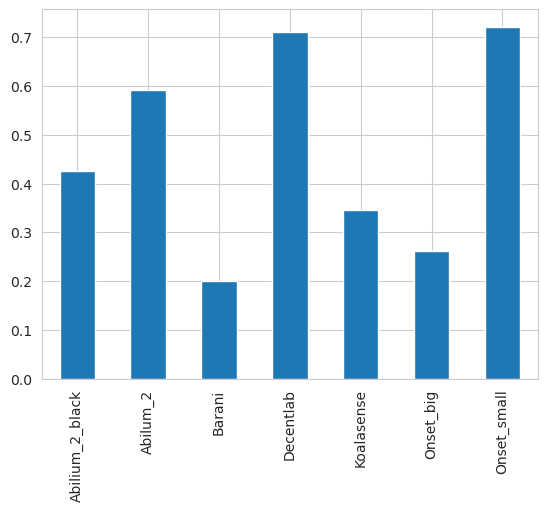

In [ ]:
pd.Series(fit_dict).plot(kind="bar")

K=1 skipped. Mean computed from data directly.
K=2 fitted in 0.035 seconds.
K=3 fitted in 0.002 seconds.
K=4 fitted in 0.003 seconds.
K=5 fitted in 0.003 seconds.
K=6 fitted in 0.003 seconds.
K=7 fitted in 0.003 seconds.


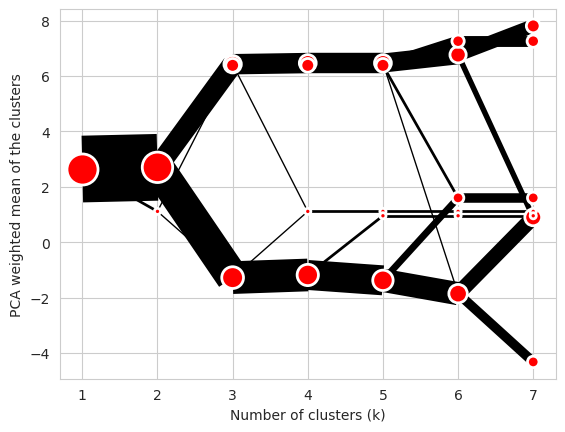

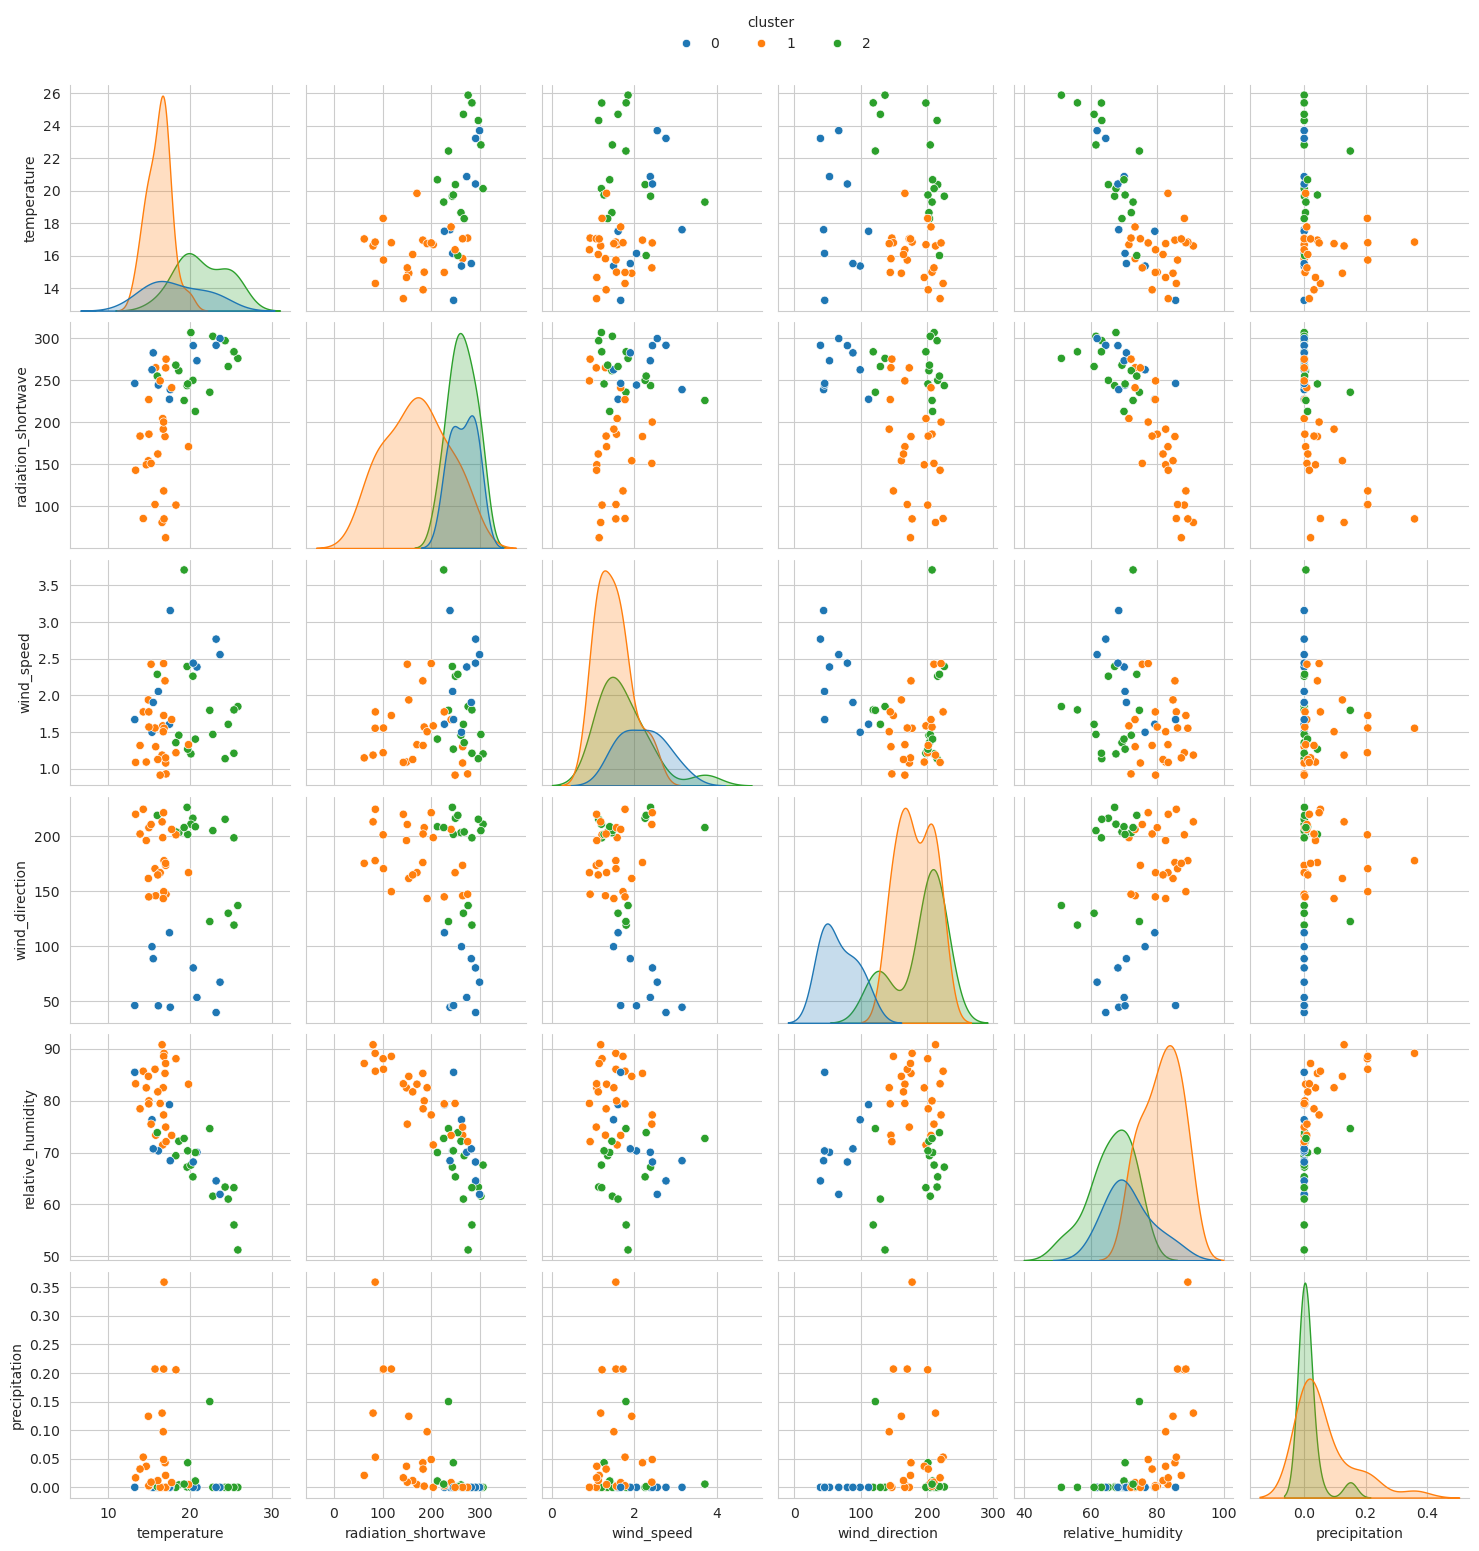

In [ ]:
X_ser = (
    pd.DataFrame(
        preprocessing.StandardScaler().fit_transform(ref_ts_df),
        index=ref_ts_df.index,
        columns=ref_ts_df.columns,
    )
    .groupby(ref_ts_df.index.date)
    .apply(lambda col_ser: col_ser.T.values)
    .apply(lambda arr: arr.flatten())
)
X_arr = np.stack(X_ser.values)
k_range = range(1, 8)
random_seed = 0
cgram = clustergram.Clustergram(k_range, random_state=random_seed).fit(X_arr)
cgram.plot()
score = cgram.davies_bouldin_score()
n_clusters = score.idxmax()
cluster_ser = pd.Series(cgram.labels_[n_clusters].values, index=X_ser.index)
g = sns.pairplot(
    ref_ts_df.resample("d").mean().assign(**{"cluster": cluster_ser}),
    hue="cluster",
    palette=sns.color_palette(n_colors=n_clusters),
)
sns.move_legend(
    g, "lower center", bbox_to_anchor=(0.5, 1), ncol=n_clusters, frameon=False
)

The clustering suggests three main types of days, namely:
- **cluster 0**: days with *mean wind direction under 120$\degree$ (N to SE)*
- **cluster 1**: days with mean wind direction over 120$\degree$ with *low mean temperature and radiation* and *high relative humidity*
- **cluster 2**: days with mean wind direction over 120$\degree$ with *high mean temperature and radiation* and *low relative humidity*

/home/martibosch/data-science/swiss-uhi-lcd/swiss_uhi_lcd/regr_utils.py:147: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  _eval_func(
/home/martibosch/data-science/swiss-uhi-lcd/swiss_uhi_lcd/regr_utils.py:147: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  _eval_func(
/home/martibosch/data-science/swiss-uhi-lcd/swiss_uhi_lcd/regr_utils.py:147: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  _eval_func(
/home/martibosch/data-science/swiss-uhi-lcd/swiss_uhi_lcd/regr_utils.py:147: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  _eval_func(
/home/martibosch/data-science/swiss-uhi-lcd/swiss_uhi_lcd/regr_utils.py:147: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  _eval_func(
/home/martibosch/data-science/swiss-uhi-lcd/swiss_uhi_lcd/regr_utils.py:147

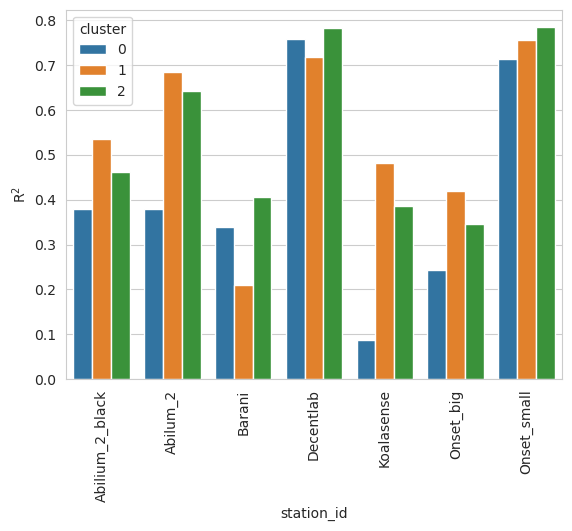

In [ ]:
cluster_params_df = pd.DataFrame()
cluster_fit_df = pd.DataFrame()
for cluster, cluster_ts_df in long_ts_df.assign(
    **{"cluster": long_ts_df["time"].dt.date.map(cluster_ser)}
).groupby("cluster"):
    _params_df, _fit_dict = ols_by_station(
        ref_ts_df, cluster_ts_df, y_col, max_window_hours=max_window_hours
    )
    cluster_params_df = pd.concat(
        [cluster_params_df, _params_df.assign(**{"cluster": cluster})]
    )
    cluster_fit_df = pd.concat(
        [
            cluster_fit_df,
            pd.Series(_fit_dict)
            .reset_index()
            .rename(columns={"index": "station_id", 0: "R$^2$"})
            .assign(**{"cluster": cluster}),
        ]
    )

ax = sns.barplot(
    cluster_fit_df,
    x="station_id",
    y="R$^2$",
    hue="cluster",
    palette=sns.color_palette(),
)
ax.tick_params(axis="x", labelrotation=90)

/tmp/ipykernel_127721/2718899134.py:1: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.catplot(


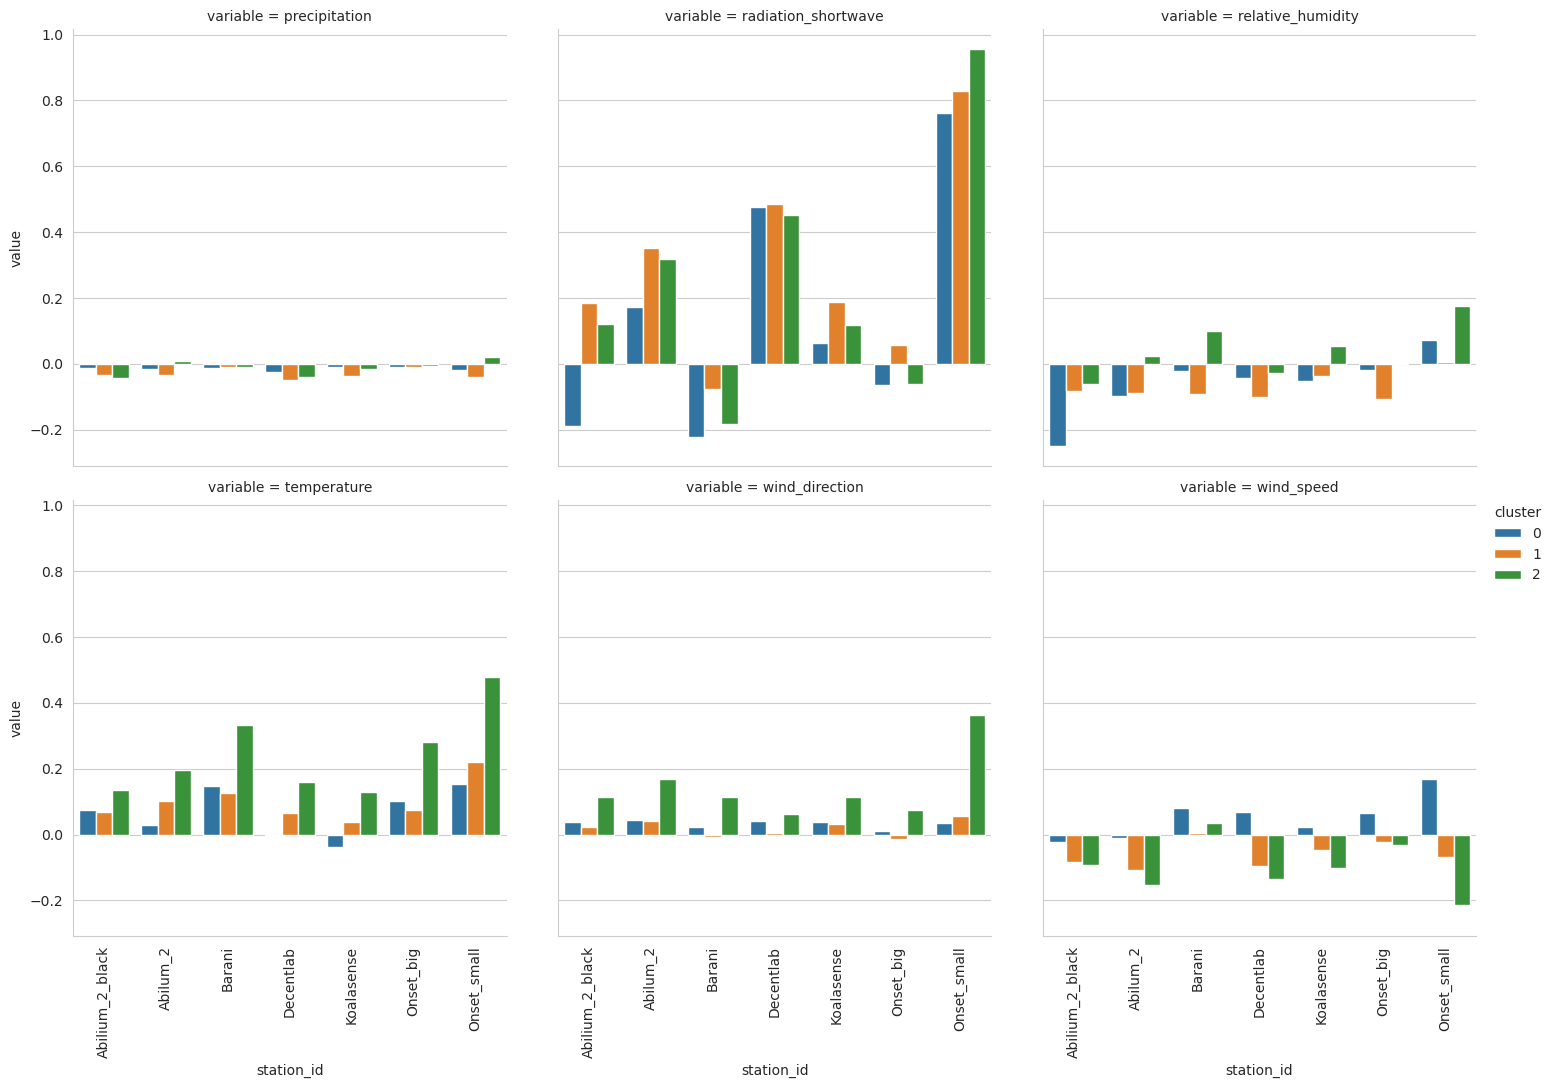

In [ ]:
g = sns.catplot(
    cluster_params_df,
    x="station_id",
    y="value",
    col="variable",
    hue="cluster",
    kind="bar",
    col_wrap=3,
    palette=sns.color_palette(),
)
g.tick_params(axis="x", labelrotation=90)

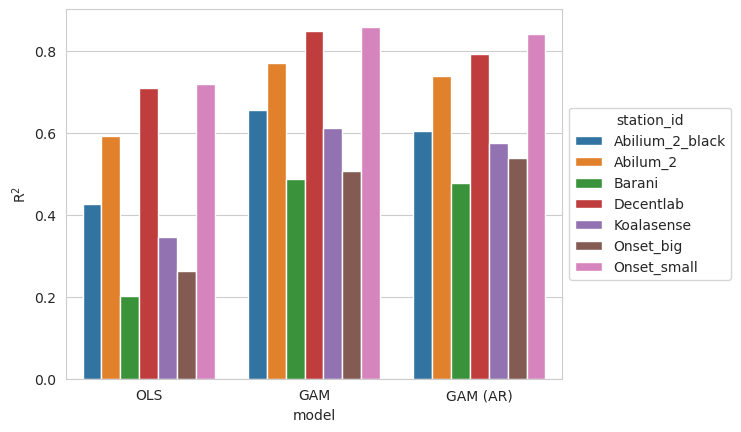

In [ ]:
# define models to compare
# compose.ForecastingPipeline
ols = pipeline.Pipeline(
    steps=[
        # ("imputer", Imputer(method="mean")),
        ("scaler", preprocessing.StandardScaler()),
        ("model", linear_model.LinearRegression()),
    ]
)
gam = pipeline.Pipeline(
    steps=[
        # ("imputer", Imputer(method="mean")),
        ("scaler", preprocessing.StandardScaler()),
        ("transformer", preprocessing.SplineTransformer(degree=3, n_knots=20)),
        ("model", linear_model.LinearRegression()),
    ]
)
# _sarimax = compose.ForecastingPipeline(
#     steps=[
#         # ("imputer", Imputer(method="mean")),
#         ("scaler", preprocessing.StandardScaler()),
#         ("model", sarimax.SARIMAX()),
#     ]
# )
gam_ar = compose.ForecastingPipeline(
    steps=[
        # ("imputer", Imputer(method="mean")),
        ("scaler", preprocessing.StandardScaler()),
        ("transformer", preprocessing.SplineTransformer(degree=3, n_knots=20)),
        ("model", auto_reg.AutoREG(lags=1, trend="n")),
    ]
)
# model_dict = {"OLS": ols, "GAM": gam, "SARIMAX": _sarimax, "GAM (AR)": gam_ar}
model_dict = {"OLS": ols, "GAM": gam, "GAM (AR)": gam_ar}

# compare them for each station
window_minutes = [60 * i for i in range(1, max_window_hours + 1)]
msr = regr_utils.MultiScaleRegression(ref_ts_df)
fit_dict = {}
fit_model_dict = {}
# res_df = regr_df[["station_id", y_col] + x_cols].copy()
res_df = pd.DataFrame()
for station_id, station_ts_df in long_ts_df.groupby("station_id"):
    X_df = msr.get_regr_df(
        station_ts_df,
        y_col,
        window_minutes,
        add_scale_to_col_name=True,
        rescale=False,
    )

    X_df = X_df.rename(
        columns={
            col: "_".join(col.split("_")[:-1])
            for col in X_df.columns.drop(["time", y_col])
        }
    )

    variables = X_df.columns.drop(["time", y_col])
    _fit_dict, _fit_model_dict, yhat = regr_utils._compare_models(
        X_df, model_dict, y_col, variables
    )
    fit_dict[station_id] = _fit_dict
    fit_model_dict[station_id] = _fit_model_dict

fit_df = pd.DataFrame(fit_dict).T.rename_axis("station_id")
# plot comparison
ax = sns.barplot(
    fit_df.reset_index().melt(
        id_vars=["station_id"], var_name="model", value_name="R$^2$"
    ),
    x="model",
    y="R$^2$",
    hue="station_id",
)
sns.move_legend(ax, "center left", bbox_to_anchor=(1, 0.5))

In [ ]:
# TODO: smarter pipeline where:
# 1. focus on Barani, Koalasense an Onset_big (maybe also Abilium_2_black
# 2. visualize relationships with each variable
# 3. try a link function to the response first
# 4. alternatively try individual transforms to the most influential variables